In [1]:
import pandas as pd
import numpy as np

In [6]:
file_path="C:/Users/Omkar Kurane/Downloads/Boots_Opticians_Analytics_Dataset.xlsx"
fact_sales = pd.read_excel(file_path, sheet_name="Fact_Sales")
fact_appointments = pd.read_excel(file_path, sheet_name="Fact_Appointments")
dim_store = pd.read_excel(file_path, sheet_name="Dim_Store")
dim_product = pd.read_excel(file_path, sheet_name="Dim_Product")
dim_customer = pd.read_excel(file_path, sheet_name="Dim_Customer")
dim_service = pd.read_excel(file_path, sheet_name="Dim_Service")
dim_date = pd.read_excel(file_path, sheet_name="Dim_Date")

In [12]:
print(fact_sales.shape)
print(fact_sales.columns.tolist())
print(fact_sales.dtypes)
fact_sales.head()

(110025, 17)
['Sale_ID', 'Date', 'Store_ID', 'Customer_ID', 'Product_ID', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Payment_Method', 'Return_Flag', 'Gross_Revenue', 'Discount_Amount', 'Net_Revenue', 'Cost', 'Gross_Margin', 'Region', 'Category ']
Sale_ID                    object
Date               datetime64[ns]
Store_ID                   object
Customer_ID                object
Product_ID                 object
Quantity                    int64
Unit_Price                float64
Discount_Pct              float64
Payment_Method             object
Return_Flag                object
Gross_Revenue             float64
Discount_Amount           float64
Net_Revenue               float64
Cost                      float64
Gross_Margin              float64
Region                     object
Category                   object
dtype: object


,Sale_ID,Date,Store_ID,Customer_ID,Product_ID,Quantity,Unit_Price,Discount_Pct,Payment_Method,Return_Flag,Gross_Revenue,Discount_Amount,Net_Revenue,Cost,Gross_Margin,Region,Category
0,T00000001,2026-03-05,S1114,C012924,P0201,1,118.81,0.00,Card,No,118.81,0.00,118.81,63.09,55.72,Wales,Spectacle Frame
1,T00000002,2025-09-24,S1100,C005089,P0247,1,96.72,0.00,Card,No,96.72,0.00,96.72,47.21,49.51,Scotland,Sunglasses
2,T00000003,2026-05-10,S1022,C014047,P0144,1,169.66,0.05,Card,No,169.66,8.48,161.18,106.29,54.89,South East,Prescription Lens
3,T00000004,2026-10-27,S1001,C019041,P0024,1,200.09,0.05,Card,No,200.09,10.00,190.09,121.87,68.22,London,Prescription Lens
4,T00000005,2025-03-15,S1052,C017644,P0163,1,122.12,0.10,Gift Card,No,122.12,12.21,109.91,55.09,54.82,Midlands,Prescription Lens


In [13]:
fact_sales.info()
fact_sales.describe()

fact_sales['Payment_Method'].value_counts()
fact_sales['Return_Flag'].value_counts()
fact_appointments['Appointment_Status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110025 entries, 0 to 110024
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Sale_ID          110025 non-null  object        
 1   Date             110025 non-null  datetime64[ns]
 2   Store_ID         110025 non-null  object        
 3   Customer_ID      110025 non-null  object        
 4   Product_ID       110025 non-null  object        
 5   Quantity         110025 non-null  int64         
 6   Unit_Price       110025 non-null  float64       
 7   Discount_Pct     110025 non-null  float64       
 8   Payment_Method   109985 non-null  object        
 9   Return_Flag      110025 non-null  object        
 10  Gross_Revenue    110025 non-null  float64       
 11  Discount_Amount  110025 non-null  float64       
 12  Net_Revenue      110025 non-null  float64       
 13  Cost             110025 non-null  float64       
 14  Gross_Margin     110

Appointment_Status
Completed      42839
Cancelled       5521
No-show         3361
Rescheduled     3279
Name: count, dtype: int64

In [14]:
fact_sales.isnull().sum()
fact_sales.duplicated().sum()
fact_sales['Sale_ID'].duplicated().sum()

fact_appointments.isnull().sum()
fact_appointments['Appointment_ID'].duplicated().sum()

np.int64(0)

In [17]:
dupes = fact_sales[fact_sales.duplicated(subset=['Sale_ID'], keep=False)]
dupes.sort_values('Sale_ID').head(10)

fact_appointments[fact_appointments['Unnamed: 12'].notnull()]

fact_appointments[['Unnamed: 9','Unnamed: 10','Unnamed: 11']].describe()

,Unnamed: 9,Unnamed: 10,Unnamed: 11
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [19]:
dupes = fact_sales[fact_sales.duplicated(subset=['Sale_ID'], keep=False)]
dupes.sort_values('Sale_ID').head(10)

fact_appointments[fact_appointments['Unnamed: 12'].notnull()]

,Appointment_ID,Date,Store_ID,Customer_ID,Service_ID,Appointment_Status,Converted_To_Sale,Booking_Channel,Wait_Days,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
5,A0000006,2026-07-10,S1101,C014019,SV07,Cancelled,No,Online,1,NaN,NaN,NaN,0.0


In [20]:
fact_appointments = fact_appointments.drop(columns=['Unnamed: 9','Unnamed: 10','Unnamed: 11','Unnamed: 12'])

In [23]:
dupes = fact_sales[fact_sales.duplicated(subset=['Sale_ID'], keep=False)]
dupes.sort_values('Sale_ID').head(5)

,Sale_ID,Date,Store_ID,Customer_ID,Product_ID,Quantity,Unit_Price,Discount_Pct,Payment_Method,Return_Flag,Gross_Revenue,Discount_Amount,Net_Revenue,Cost,Gross_Margin,Region,Category
0,T00000001,2026-03-05,S1114,C012924,P0201,1,118.81,0.00,Card,No,118.81,0.00,118.81,63.09,55.72,Wales,Spectacle Frame
110000,T00000001,2026-03-05,S1114,C012924,P0201,1,118.81,0.00,Card,No,118.81,0.00,118.81,63.09,55.72,Wales,Spectacle Frame
110001,T00000002,2025-09-24,S1100,C005089,P0247,1,96.72,0.00,Card,No,96.72,0.00,96.72,47.21,49.51,Scotland,Sunglasses
1,T00000002,2025-09-24,S1100,C005089,P0247,1,96.72,0.00,Card,No,96.72,0.00,96.72,47.21,49.51,Scotland,Sunglasses
2,T00000003,2026-05-10,S1022,C014047,P0144,1,169.66,0.05,Card,No,169.66,8.48,161.18,106.29,54.89,South East,Prescription Lens


In [24]:
fact_sales = fact_sales.drop_duplicates(subset=['Sale_ID'], keep='first')
print(fact_sales.shape)  

(110000, 17)


In [25]:
fact_sales['Payment_Method'] = fact_sales['Payment_Method'].fillna('Unknown')
fact_appointments['Booking_Channel'] = fact_appointments['Booking_Channel'].fillna('Unknown')

C:\Users\Omkar Kurane\AppData\Local\Temp\ipykernel_45660\1613250801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_sales['Payment_Method'] = fact_sales['Payment_Method'].fillna('Unknown')


In [29]:
# IQR method for Net_Revenue
Q1 = fact_sales['Net_Revenue'].quantile(0.25)
Q3 = fact_sales['Net_Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

outliers = fact_sales[(fact_sales['Net_Revenue'] < lower_bound) | (fact_sales['Net_Revenue'] > upper_bound)]
print("Number of outliers:", outliers.shape[0])
print("Outlier percentage:", round(outliers.shape[0] / fact_sales.shape[0] * 100, 2), "%")

outliers[['Sale_ID','Net_Revenue','Product_ID','Category','Quantity','Unit_Price']].sort_values('Net_Revenue', ascending=False).head(10)

Q1: 53.29, Q3: 223.0, IQR: 169.71
Lower bound: -201.275, Upper bound: 477.565
Number of outliers: 3103
Outlier percentage: 2.82 %


,Sale_ID,Net_Revenue,Product_ID,Category,Quantity,Unit_Price
107934,T00107935,1306.08,P0102,Spectacle Frame,3,435.36
39894,T00039895,1306.08,P0102,Spectacle Frame,3,435.36
94237,T00094238,1306.08,P0102,Spectacle Frame,3,435.36
12323,T00012324,1306.08,P0102,Spectacle Frame,3,435.36
73075,T00073076,1248.06,P0292,Spectacle Frame,3,416.02
77278,T00077279,1248.06,P0292,Spectacle Frame,3,416.02
107216,T00107217,1248.06,P0292,Spectacle Frame,3,416.02
9339,T00009340,1248.06,P0292,Spectacle Frame,3,416.02
100531,T00100532,1247.97,P0264,Prescription Lens,3,415.99
102810,T00102811,1247.97,P0264,Prescription Lens,3,415.99


In [30]:
Q1_m = fact_sales['Gross_Margin'].quantile(0.25)
Q3_m = fact_sales['Gross_Margin'].quantile(0.75)
IQR_m = Q3_m - Q1_m

lower_m = Q1_m - 1.5 * IQR_m
upper_m = Q3_m + 1.5 * IQR_m

outliers_margin = fact_sales[(fact_sales['Gross_Margin'] < lower_m) | (fact_sales['Gross_Margin'] > upper_m)]
print("Margin outliers:", outliers_margin.shape[0])

Margin outliers: 3483


In [31]:
outliers['Product_ID'].value_counts().head(10)

Product_ID
P0092    72
P0214    70
P0286    67
P0204    66
P0032    65
P0222    64
P0124    63
P0094    62
P0056    61
P0122    61
Name: count, dtype: int64

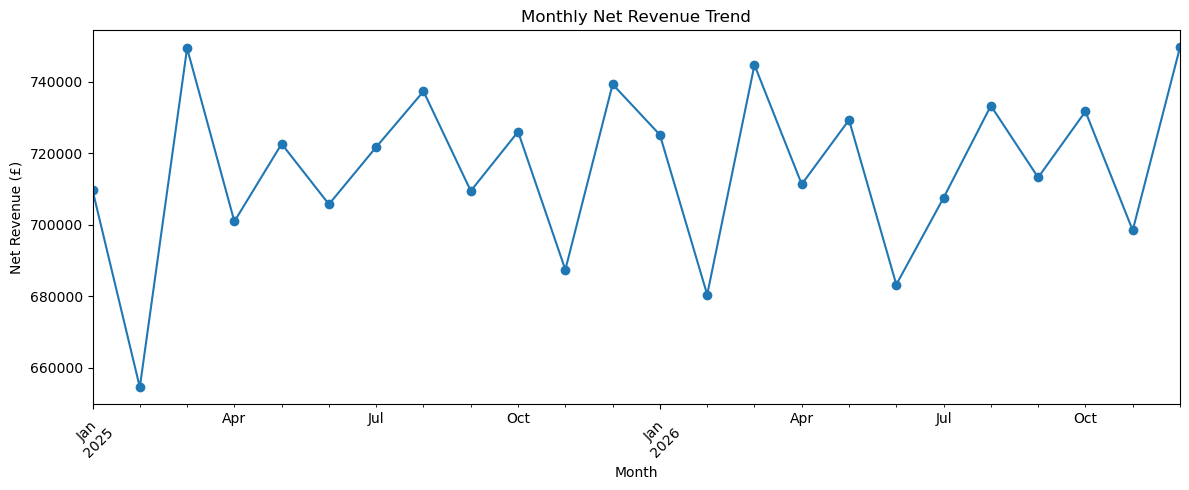

In [32]:
import matplotlib.pyplot as plt

# Monthly revenue trend
fact_sales['Month_Year'] = fact_sales['Date'].dt.to_period('M')
monthly_revenue = fact_sales.groupby('Month_Year')['Net_Revenue'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Net Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Net Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Region
Scotland      2138426.95
South East    2123593.43
South West    2121860.99
Yorkshire     2102027.05
North West    2094813.93
Midlands      2067039.09
North East    1714403.59
Wales         1682967.65
London        1127337.68
Name: Net_Revenue, dtype: float64


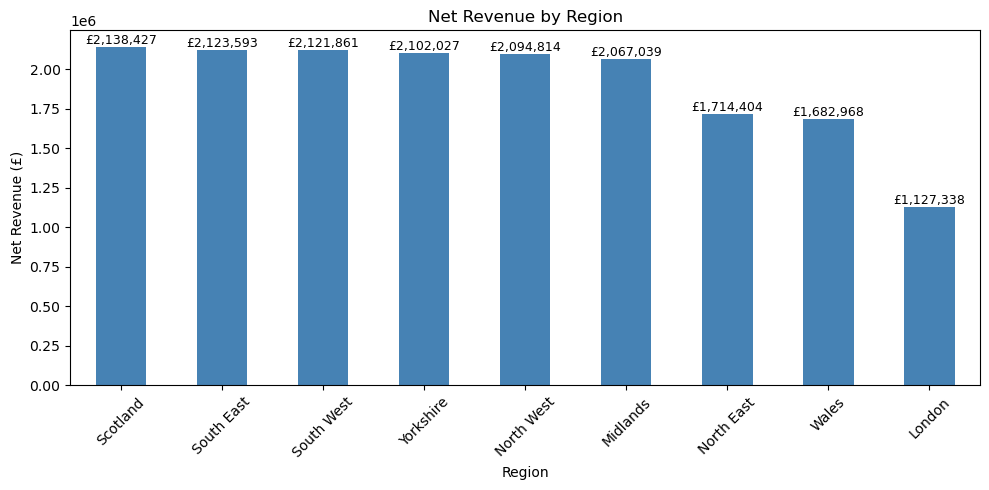

In [36]:
# Regional performance
region_revenue = fact_sales.groupby('Region')['Net_Revenue'].sum().sort_values(ascending=False)
print(region_revenue)

plt.figure(figsize=(10,5))
ax = region_revenue.plot(kind='bar', color='steelblue')
plt.title('Net Revenue by Region')
plt.ylabel('Net Revenue (£)')
plt.xticks(rotation=45)
for i, v in enumerate(region_revenue):
    ax.text(i, v, f'£{v:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Store_ID
S1013    156714.92
S1110    153341.56
S1035    152192.44
S1100    152147.03
S1033    150201.79
S1089    149289.80
S1095    149137.36
S1104    149119.67
S1049    148732.87
S1015    148214.75
Name: Net_Revenue, dtype: float64


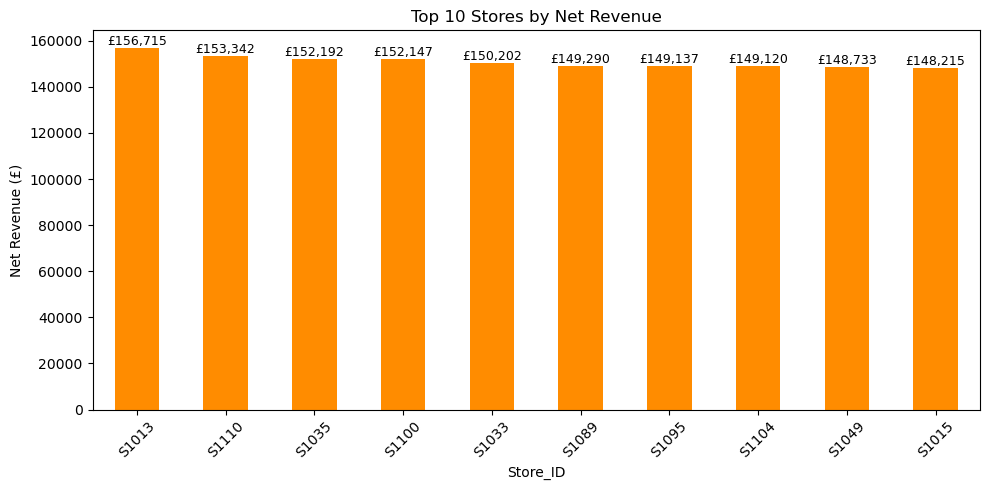

In [37]:
# Store-level performance (top 10)
store_revenue = fact_sales.groupby('Store_ID')['Net_Revenue'].sum().sort_values(ascending=False).head(10)
print(store_revenue)

plt.figure(figsize=(10,5))
ax = store_revenue.plot(kind='bar', color='darkorange')
plt.title('Top 10 Stores by Net Revenue')
plt.ylabel('Net Revenue (£)')
plt.xticks(rotation=45)
for i, v in enumerate(store_revenue):
    ax.text(i, v, f'£{v:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Category
Prescription Lens    6620225.71
Spectacle Frame      5094737.05
Sunglasses           4186560.85
Contact Lenses       1083030.23
Lens Care             187916.52
Name: Net_Revenue, dtype: float64


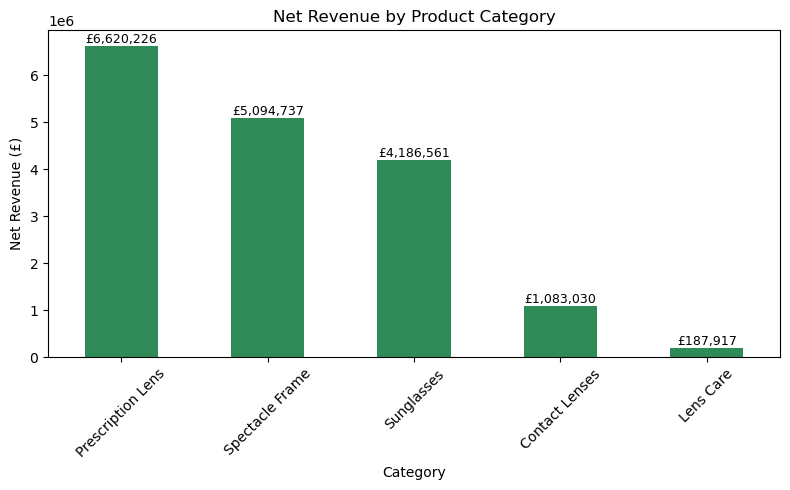

In [38]:
# Category performance
category_revenue = fact_sales.groupby('Category')['Net_Revenue'].sum().sort_values(ascending=False)
print(category_revenue)

plt.figure(figsize=(8,5))
ax = category_revenue.plot(kind='bar', color='seagreen')
plt.title('Net Revenue by Product Category')
plt.ylabel('Net Revenue (£)')
plt.xticks(rotation=45)
for i, v in enumerate(category_revenue):
    ax.text(i, v, f'£{v:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [40]:
# Appointment status breakdown
status_counts = fact_appointments['Appointment_Status'].value_counts()
print(status_counts)
print(round(status_counts / status_counts.sum() * 100, 2))
# No-show rate
no_show_rate = (fact_appointments['Appointment_Status'] == 'No-show').sum() / len(fact_appointments) * 100
print(f"No-show rate: {no_show_rate:.2f}%")
# Conversion rate (appointment -> sale)
conversion_rate = (fact_appointments['Converted_To_Sale'] == 'Yes').sum() / len(fact_appointments) * 100
print(f"Conversion rate: {conversion_rate:.2f}%")
# Conversion by service
service_conversion = fact_appointments.groupby('Service_ID')['Converted_To_Sale'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
print(service_conversion)
# Conversion by appointment status
status_conversion = fact_appointments.groupby('Appointment_Status')['Converted_To_Sale'].apply(lambda x: (x=='Yes').mean()*100)
print(status_conversion)

Appointment_Status
Completed      42839
Cancelled       5521
No-show         3361
Rescheduled     3279
Name: count, dtype: int64
Appointment_Status
Completed      77.89
Cancelled      10.04
No-show         6.11
Rescheduled     5.96
Name: count, dtype: float64
No-show rate: 6.11%
Conversion rate: 37.40%
Service_ID
SV06    38.369231
SV07    38.169194
SV05    37.711670
SV04    37.448809
SV03    37.321675
SV01    37.246525
SV02    36.991007
SV08    36.507240
Name: Converted_To_Sale, dtype: float64
Appointment_Status
Cancelled       0.00000
Completed      48.01466
No-show         0.00000
Rescheduled     0.00000
Name: Converted_To_Sale, dtype: float64


In [41]:
# Merge Fact_Appointments with Dim_Store (Region) and Dim_Service (Service_Name)
fact_appointments_merged = fact_appointments.merge(
    dim_store[['Store_ID','Region']], on='Store_ID', how='left'
).merge(
    dim_service[['Service_ID','Service_Name']], on='Service_ID', how='left'
)

print(fact_appointments_merged.shape)
fact_appointments_merged.head()

# Check for any unmatched keys (should be 0)
print(fact_appointments_merged['Region'].isnull().sum())
print(fact_appointments_merged['Service_Name'].isnull().sum())

(55000, 11)
0
0


In [42]:
# Conversion by actual service name
service_conversion_named = fact_appointments_merged.groupby('Service_Name')['Converted_To_Sale'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
print(service_conversion_named)

# No-show rate by region
noshow_by_region = fact_appointments_merged.groupby('Region')['Appointment_Status'].apply(lambda x: (x=='No-show').mean()*100).sort_values(ascending=False)
print(noshow_by_region)

# Appointment volume by region
appt_volume_by_region = fact_appointments_merged.groupby('Region')['Appointment_ID'].count().sort_values(ascending=False)
print(appt_volume_by_region)

Service_Name
Dry Eye Evaluation                   38.369231
NHS Eye Test                         38.169194
Contact Lens Trial                   37.711670
Contact Lens Consultation            37.448809
Ultimate Eye Test - OCT + Optomap    37.321675
Essential Eye Test                   37.246525
Advanced Eye Test - OCT              36.991007
Dispensing / Collection              36.507240
Name: Converted_To_Sale, dtype: float64
Region
Wales         6.512567
Yorkshire     6.288551
South East    6.208005
North West    6.143445
South West    6.102510
Midlands      6.090776
Scotland      5.978985
London        5.828729
North East    5.712166
Name: Appointment_Status, dtype: float64
Region
South East    6846
Midlands      6830
North West    6804
Scotland      6757
South West    6653
Yorkshire     6647
Wales         5451
North East    5392
London        3620
Name: Appointment_ID, dtype: int64


In [43]:
appt_per_store = (appt_volume_by_region / store_count_by_region).sort_values(ascending=False)
print(appt_per_store)

Region
South East    456.400000
Midlands      455.333333
Wales         454.250000
North West    453.600000
London        452.500000
Scotland      450.466667
North East    449.333333
South West    443.533333
Yorkshire     443.133333
dtype: float64


In [ ]:
#Data quality: Clean dataset overall — 40 nulls in Payment_Method, 30 in Booking_Channel (filled as 'Unknown'); 25 exact duplicate Sale_IDs (dropped, likely intentionally appended); 4 unused columns in Fact_Appointments (dropped)

#Outliers: 2.82% of Net_Revenue rows flagged by IQR, but all legitimate — high-value Quantity=3 purchases of premium frames/lenses, not errors

#Regional revenue: Looked uneven raw (London lowest), but per-store average is uniform (~£138K–143K) across all regions — driven entirely by store count, not performance

#Category mix: Prescription Lens + Spectacle Frame = 70%+ of revenue; Lens Care is a minor add-on

#Appointments: 77.9% Completed, 22% lost to no-shows/cancellations/reschedules; conversion rate 37.4% overall

#Conversion: Flat across all services (~36.5–38.4%) — not service-dependent. Only Completed appointments convert (48%); everything else converts at 0%. Key lever = reduce lost appointments, not promote specific services

#No-shows: Consistent 5.7–6.5% across all regions — systemic issue, not regional, so fixes should be chain-wide

#Referential integrity: Merges across Store/Service/Product all clean, zero unmatched keys

In [44]:
revenue_stats = fact_sales['Net_Revenue'].agg(['mean', 'median', 'std', 'var'])
print(revenue_stats)

mean        156.113367
median      124.810000
std         137.047386
var       18781.985928
Name: Net_Revenue, dtype: float64


In [45]:
regional_stats = fact_sales.groupby('Region')['Net_Revenue'].agg(['mean', 'std', 'var']).sort_values('std', ascending=False)
print(regional_stats)

# Coefficient of variation - lets you compare volatility fairly even if means differ
regional_stats['cv'] = regional_stats['std'] / regional_stats['mean']
print(regional_stats.sort_values('cv', ascending=False))

                  mean         std           var
Region                                          
North East  157.965870  138.751966  19252.107962
South West  157.454808  138.506839  19184.144405
London      156.748843  137.042649  18780.687719
Scotland    155.273522  137.018814  18774.155331
South East  156.445663  136.892351  18739.515887
Wales       154.869573  136.688805  18683.829484
Yorkshire   156.017743  136.381626  18599.947830
North West  156.073158  136.220676  18556.072704
Midlands    154.591212  136.157767  18538.937385
                  mean         std           var        cv
Region                                                    
Wales       154.869573  136.688805  18683.829484  0.882606
Scotland    155.273522  137.018814  18774.155331  0.882435
Midlands    154.591212  136.157767  18538.937385  0.880760
South West  157.454808  138.506839  19184.144405  0.879661
North East  157.965870  138.751966  19252.107962  0.878367
South East  156.445663  136.892351  18739.515887

In [46]:
import numpy as np
np.random.seed(42)  # reproducibility - important, interviewers will ask why you set this

sample = fact_sales['Net_Revenue'].sample(n=1000, random_state=42)

print("Population mean:", fact_sales['Net_Revenue'].mean())
print("Sample mean:", sample.mean())
print("Population std:", fact_sales['Net_Revenue'].std())
print("Sample std:", sample.std())

Population mean: 156.1133669090909
Sample mean: 148.77313
Population std: 137.04738570284758
Sample std: 132.59910321520502


In [47]:
# No-show probability
p_noshow = (fact_appointments['Appointment_Status'] == 'No-show').mean()
print(f"P(No-show) = {p_noshow:.4f}")

# Conversion probability, overall and conditional on completion
p_conversion = (fact_appointments['Converted_To_Sale'] == 'Yes').mean()
p_conversion_given_completed = fact_appointments[fact_appointments['Appointment_Status']=='Completed']['Converted_To_Sale'].apply(lambda x: x=='Yes').mean()
print(f"P(Conversion) = {p_conversion:.4f}")
print(f"P(Conversion | Completed) = {p_conversion_given_completed:.4f}")

P(No-show) = 0.0611
P(Conversion) = 0.3740
P(Conversion | Completed) = 0.4801


In [48]:
store_revenue = fact_sales.groupby('Store_ID')['Net_Revenue'].sum()
print(store_revenue.describe(percentiles=[.25, .5, .75, .9]))

count       122.000000
mean     140757.953770
std        5587.871126
min      125368.590000
25%      137310.937500
50%      140812.065000
75%      144584.605000
90%      147756.681000
max      156714.920000
Name: Net_Revenue, dtype: float64


In [49]:
fact_sales.to_csv('Fact_Sales_Clean.csv', index=False)
fact_appointments.to_csv('Fact_Appointments_Clean.csv', index=False)
dim_store.to_csv('Dim_Store.csv', index=False)
dim_product.to_csv('Dim_Product.csv', index=False)
dim_customer.to_csv('Dim_Customer.csv', index=False)
dim_service.to_csv('Dim_Service.csv', index=False)
dim_date.to_csv('Dim_Date.csv', index=False)

print("Saved all files")

Saved all files


In [50]:
import os
print(os.getcwd())


C:\Users\Omkar Kurane
